#### Recommendation System Experimentation

In [39]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning / Model Validation 
from surprise import accuracy
from surprise import CoClustering
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise import CoClustering
from surprise.model_selection import KFold
from surprise.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from surprise.model_selection import GridSearchCV
from sklearn.metrics import ndcg_score

from collections import defaultdict

##### Popularity Based Recommendation System

In [114]:
combined_ratings = pd.read_csv("../data/user_movielens_ratings.csv")
ml_movies = pd.read_csv("../data/movielens/ml_movies_with_tmdbId.csv")

In [ ]:
combined_ratings

(31995734, 3)

In [117]:
ml_movies.head()

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0


In [4]:
# Get movies with highest average ratings
combined_ratings_w_name = combined_ratings.merge(ml_movies[["tmdbId", "title"]], on="tmdbId", how="left")

In [5]:
rating_counts = (
    combined_ratings_w_name
    .groupby("tmdbId")["userId"]
    .count()
)

user_611_movies = combined_ratings_w_name.loc[
    combined_ratings_w_name["userId"] == 611,
    "tmdbId",
]

movie_thresh = rating_counts[
    (rating_counts >= 10) |
    (rating_counts.index.isin(user_611_movies))
].sort_values(ascending=False)

In [6]:
combined_ratings_filtered = combined_ratings_w_name[combined_ratings_w_name["tmdbId"].isin(movie_thresh.index)]
combined_ratings_filtered.head()

,userId,tmdbId,rating,title
0,1,862.0,4.0,Toy Story (1995)
1,1,15602.0,4.0,Grumpier Old Men (1995)
2,1,949.0,4.0,Heat (1995)
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"


In [7]:
tmdb_titles = pd.read_csv("../data/enriched_movies.csv")
tmdb_titles.head()

,Name,Year,Rating,tmdb_id,genres,director,cast
0,The Usual Suspects,1995,5.0,629.0,"['Drama', 'Crime', 'Thriller']",Bryan Singer,"['Stephen Baldwin', 'Gabriel Byrne', 'Benicio ..."
1,Good Will Hunting,1997,5.0,489.0,['Drama'],Gus Van Sant,"['Matt Damon', 'Robin Williams', 'Ben Affleck'..."
2,Scream,1996,5.0,4232.0,"['Crime', 'Horror', 'Mystery']",Wes Craven,"['Neve Campbell', 'Skeet Ulrich', 'Rose McGowa..."
3,A Few Good Men,1992,5.0,881.0,['Drama'],Rob Reiner,"['Tom Cruise', 'Jack Nicholson', 'Demi Moore',..."
4,No Country for Old Men,2007,5.0,6977.0,"['Crime', 'Thriller', 'Western']",Joel Coen,"['Javier Bardem', 'Tommy Lee Jones', 'Josh Bro..."


In [8]:
combined_ratings_final = (
    combined_ratings_filtered
    .merge(
        tmdb_titles[["tmdb_id", "Name"]],
        left_on="tmdbId",
        right_on="tmdb_id",
        how="left"
    )
)

combined_ratings_final["title"] = (
    combined_ratings_final["title"]
    .fillna(combined_ratings_final["Name"])
)

combined_ratings_final = combined_ratings_final.drop(columns=["Name"])

In [9]:
# Get movies with most number of watchers
movie_freq = combined_ratings_final.groupby("title")["userId"].count().sort_values(ascending=False)

In [10]:
# Get highest rated movies with at least 10 ratings
highest_rated_movies = combined_ratings_final.groupby("title").mean().sort_values(("rating"), ascending=False)

In [11]:
popular_movies = pd.DataFrame({"avg_rating": highest_rated_movies["rating"], "num_ratings": movie_freq})

In [12]:
popular_movies.sort_values("avg_rating", ascending=False).head(10)

,avg_rating,num_ratings
title,,
G.N.A.R.,5.000000,1
Free Solo,5.000000,1
Dune: Part Two,5.000000,1
Moonlight,4.750000,2
Memories of Murder (Salinui chueok) (2003),4.666667,6
"Three Billboards Outside Ebbing, Missouri (2017)",4.666667,9
Secrets & Lies (1996),4.590909,11
Guess Who's Coming to Dinner (1967),4.545455,11
Paths of Glory (1957),4.541667,12


#### Popularity Model (Baseline)

In [13]:
# Create a function to get recommendations based on rating with a minimum number of ratings
def top_movies(min_ratings=10, top_n=10):
    popular_movies_filtered = popular_movies[popular_movies["num_ratings"] >= min_ratings]
    return popular_movies_filtered.sort_values("avg_rating", ascending=False).head(top_n)

In [14]:
# Get movie recommendations with at least 100 ratings and return the top 10
top_movies(200, 10)

,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.429245,318
Fight Club (1999),4.271689,219
"Usual Suspects, The (1995)",4.241463,205
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Schindler's List (1993),4.225000,220
Star Wars: Episode V - The Empire Strikes Back (1980),4.215640,211
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),4.207500,200
Pulp Fiction (1994),4.198052,308
"Matrix, The (1999)",4.192446,278


#### User - User Collaborative Filtering

In [15]:
# Instantiate the reader and the dataset, then split the dataset into training and testing sets
reader = Reader(rating_scale=(0.5, 5.0))
dataset = Dataset.load_from_df(combined_ratings_final[['userId', 'tmdbId', 'rating']], reader)
trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)

In [16]:
# Function to evaluate the model
def precision_recall_at_k(model, k=30, threshold=1.5):

    user_est_true = defaultdict(list)
    predictions = model.test(testset)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 1
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 1

    precision = round(sum(prec for prec in precisions.values()) / len(precisions), 3)
    recall = round(sum(rec for rec in recalls.values()) / len(recalls), 3)

    print(f'RMSE: {accuracy.rmse(predictions, verbose=False)}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {2 * (precision * recall) / (precision + recall)}')



In [17]:
# Build user user collaborative filtering model using KNNBasic
sim_options = {'name': 'cosine', 'user_based': True}
user_user_model = KNNBasic(sim_options=sim_options, random_state=42, verbose=False)
user_user_model.fit(trainset)

# Evaluate the model
precision_recall_at_k(user_user_model, k=30, threshold=1.5)

RMSE: 0.9292493833227065
Precision: 0.966
Recall: 0.888
F1 Score: 0.9253592233009709


##### This initial user user model has good precision and recall scores. Since we aren't predicting exact stars (ratings), we won't optimize on RMSE. The goal of the recommendation system is to find movies the user hasn't seen that are relevant to them, not exactly how they would rate a single movie. In practice, a list will be returned and one movie will be selected.

##### We will save optimization for the next workbook where we compare all of the optimized models

### Item Item Collaaborateve Filtering

In [18]:
# Build item item collaborative filtering model using KNNBasic
sim_options = {'name': 'cosine', 'user_based': False}  # Item-item collaborative filtering
item_item_model = KNNBasic(sim_options=sim_options, random_state=42, verbose=False)
item_item_model.fit(trainset)

# Evaluate the model
precision_recall_at_k(item_item_model, k=30, threshold=1.5)

RMSE: 0.9255623562891565
Precision: 0.963
Recall: 0.885
F1 Score: 0.9223538961038962


In [19]:
# Lets take a look at teh ratings STD and see if the RMSE tells us anything about the model performance
print(f'Ratings STD: {combined_ratings_final["rating"].std()}')

Ratings STD: 1.0176259130797303


##### Look at predictions for user user vs item item for a movie I have seen but did not rank. I saw Hellboy a while ago and did not like it. I never ranked it so the model treats it as if I have never seen it. Let's see how it ranks Hellboy (assume another 2.5 ranking)

In [22]:
user_user_model.predict(611, 7373, r_ui=2, verbose=True)

user: 611        item: 7373       r_ui = 2.00   est = 3.57   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=611, iid=7373, r_ui=2, est=np.float64(3.573516107763313), details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [23]:
item_item_model.predict(611, 7373, r_ui=2, verbose=True)

user: 611        item: 7373       r_ui = 2.00   est = 3.57   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=611, iid=7373, r_ui=2, est=np.float64(3.573516107763313), details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

##### Both of these models seem to be returning high ratings no matter what. I purposefully chose movies that I do not like to show the impact of the ratings distribution on KNN predictions. This may be due to the fact that KNN often times regresses to the global mean. If the data shows more high ratings (ratings > 3 start), then it would make sense for the predictions to skew higher as well.

##### Let's check the distribution of ratings

In [24]:
print(combined_ratings_final["rating"].describe())

print(
    combined_ratings_final["rating"]
    .value_counts(normalize=True)
    .sort_index()
)

count    81522.000000
mean         3.574495
std          1.017626
min          0.500000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64
rating
0.5    0.011273
1.0    0.024423
1.5    0.013824
2.0    0.066264
2.5    0.049741
3.0    0.196818
3.5    0.126861
4.0    0.276870
4.5    0.089510
5.0    0.144415
Name: proportion, dtype: float64


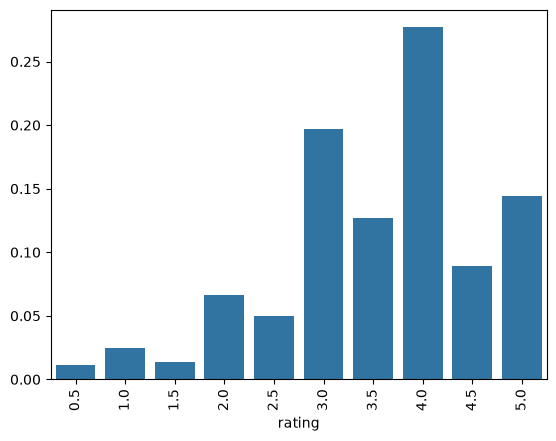

In [107]:
ratings_dist = combined_ratings_final["rating"].value_counts(normalize=True).sort_index()

sns.barplot(x=ratings_dist.index, y=ratings_dist.values)
plt.xticks(rotation=90)
plt.show()

In [25]:
predictions = item_item_model.test(testset)

predicted_ratings = [
    pred.est
    for pred in predictions
]

pd.Series(predicted_ratings).describe()

count    16305.000000
mean         3.557291
std          0.499425
min          1.268215
25%          3.249634
50%          3.589489
75%          3.900948
max          5.000000
dtype: float64

##### The mean rating in the data as well as the mean prediction are high, and the standard deviation in predictions is relatively low. 83.5% of ratings are 3 stars or greater. Over half of the ratings in the data are 4 stars or greater. The predictions skewing high makes sense since the KNN user user and item item tend to fall back to the mean especially in sparse matrices where there are not sufficient neighbors to use for prediction evidence

### Matrix Factorization (SVD)

In [44]:
# Build baseline model
svd_model = SVD(random_state=42)
svd_model.fit(trainset)
precision_recall_at_k(svd_model)

RMSE: 0.841756254844825
Precision: 0.965
Recall: 0.887
F1 Score: 0.9243574514038878


##### The baseline model for SVD performs better than collaborative filtering based on RMSE. We will optimize these in the next workbook for a true model comparison not solely looking at RMSE

In [27]:
# Movies I have seen with my ratings
combined_ratings_final[combined_ratings_final["userId"] == 611].sort_values("rating", ascending=False).head(150)

,userId,tmdbId,rating,title,tmdb_id
81262,611,629.0,5.0,"Usual Suspects, The (1995)",629.0
81329,611,1213.0,5.0,"Talented Mr. Ripley, The (1999)",1213.0
81468,611,9408.0,5.0,Surf's Up (2007),9408.0
81367,611,693134.0,5.0,Dune: Part Two,693134.0
81485,611,1018.0,5.0,Mulholland Drive (2001),1018.0
...,...,...,...,...,...
81493,611,395834.0,3.5,Wind River (2017),395834.0
81507,611,1275779.0,3.5,Disclosure Day,1275779.0
81480,611,36557.0,3.5,Casino Royale (2006),36557.0
81432,611,4944.0,3.5,Burn After Reading (2008),4944.0


In [50]:
print(f'Apocalypse Now Ranking: {svd_model.predict(611, 28.0, r_ui=2, verbose=True)}') # real ranking: 5
print(f'Old Boy Ranking: {svd_model.predict(611, 670.0, r_ui=2, verbose=True)}') # real ranking: 4.5
print(f'Burn After Reading Ranking: {svd_model.predict(611, 4944.0, r_ui=2, verbose=True)}') # real ranking: 3.5
print(f'Red Eye Ranking: {svd_model.predict(611, 11460.0, r_ui=2, verbose=True)}') # real ranking: 2.5
print(f'The Ice Man Ranking: {svd_model.predict(611, 68812.0, r_ui=2, verbose=True)}') # real ranking: 1.5

user: 611        item: 28.0       r_ui = 2.00   est = 4.44   {'was_impossible': False}
Apocalypse Now Ranking: user: 611        item: 28.0       r_ui = 2.00   est = 4.44   {'was_impossible': False}
user: 611        item: 670.0      r_ui = 2.00   est = 4.09   {'was_impossible': False}
Old Boy Ranking: user: 611        item: 670.0      r_ui = 2.00   est = 4.09   {'was_impossible': False}
user: 611        item: 4944.0     r_ui = 2.00   est = 3.50   {'was_impossible': False}
Burn After Reading Ranking: user: 611        item: 4944.0     r_ui = 2.00   est = 3.50   {'was_impossible': False}
user: 611        item: 11460.0    r_ui = 2.00   est = 3.30   {'was_impossible': False}
Red Eye Ranking: user: 611        item: 11460.0    r_ui = 2.00   est = 3.30   {'was_impossible': False}
user: 611        item: 68812.0    r_ui = 2.00   est = 3.28   {'was_impossible': False}
The Ice Man Ranking: user: 611        item: 68812.0    r_ui = 2.00   est = 3.28   {'was_impossible': False}


#### Looking at how SVD predicts my rankings, the ranking values seem to be compressed, not completely incorrect. It would still rank order all of these movies in the correct way, just doesn't necessarily predict the exact right star value which is not the goal of this system. These results show the model is still useful for ranking even before being tuned.

In [29]:
# Look at my own ranking distribution
combined_ratings_final[combined_ratings_final["userId"] == 611]["rating"].value_counts(normalize=True).sort_index()

rating
1.5    0.007692
2.0    0.007692
2.5    0.057692
3.0    0.180769
3.5    0.219231
4.0    0.261538
4.5    0.192308
5.0    0.073077
Name: proportion, dtype: float64

#### It seems that my own rankings skew towards higher star values. It also seems that my lowest ranking movies are not in the data

In [35]:
combined_ratings_final.head(50)

,userId,tmdbId,rating,title
0,1,862.0,4.0,Toy Story (1995)
1,1,15602.0,4.0,Grumpier Old Men (1995)
2,1,949.0,4.0,Heat (1995)
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"
5,1,755.0,3.0,From Dusk Till Dawn (1996)
6,1,13685.0,5.0,Bottle Rocket (1996)
7,1,197.0,4.0,Braveheart (1995)
8,1,11780.0,5.0,Rob Roy (1995)
9,1,1775.0,5.0,Canadian Bacon (1995)


In [ ]:
# drop second tmdbId column
combined_ratings_final = combined_ratings_final[["userId","tmdbId", "rating", "title"]]

In [36]:
combined_ratings_final[combined_ratings_final["rating"]==5]

,userId,tmdbId,rating,title
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"
6,1,13685.0,5.0,Bottle Rocket (1996)
8,1,11780.0,5.0,Rob Roy (1995)
9,1,1775.0,5.0,Canadian Bacon (1995)
...,...,...,...,...
81421,611,139412.0,5.0,G.N.A.R.
81433,611,273481.0,5.0,Sicario (2015)
81444,611,171274.0,5.0,Inherent Vice (2014)
81468,611,9408.0,5.0,Surf's Up (2007)


In [40]:
## MODEL LIST
# user_user_model
# item_item_model
# svd_model
# cocluster_model
# popularity model: top_movies(min_obs, top_n)

### CoClustering Model

In [41]:
# Create baseline CoClustering model
cocluster_model = CoClustering(random_state=1)
cocluster_model.fit(trainset)

precision_recall_at_k(cocluster_model)

RMSE: 0.8904239981453171
Precision: 0.967
Recall: 0.884
F1 Score: 0.9236391139924366


#### Run same prediction experiment as I did with SVD

In [56]:
def model_pred_vs_actual(model, movieID, userID):
    prediction = model.predict(userID, movieID, verbose=False).est

    movie = combined_ratings_final.loc[
        (combined_ratings_final["userId"] == userID) &
        (combined_ratings_final["tmdbId"] == movieID)
    ].iloc[0]

    actual_rating = movie["rating"]
    movie_title = movie["title"]

    print(
        f"{movie_title} | "
        f"{model.__class__.__name__} prediction: {prediction:.2f} | "
        f"Actual rating: {actual_rating}"
    )

In [58]:
model_pred_vs_actual(cocluster_model, 28, 611)
model_pred_vs_actual(cocluster_model, 670, 611)
model_pred_vs_actual(cocluster_model, 4944, 611)
model_pred_vs_actual(cocluster_model, 11460, 611)
model_pred_vs_actual(cocluster_model, 68812, 611)

Apocalypse Now (1979) | CoClustering prediction: 4.40 | Actual rating: 5.0
Old Boy (2003) | CoClustering prediction: 3.75 | Actual rating: 4.5
Burn After Reading (2008) | CoClustering prediction: 3.42 | Actual rating: 3.5
Red Eye (2005) | CoClustering prediction: 3.16 | Actual rating: 2.5
Iceman, The (2012) | CoClustering prediction: 2.05 | Actual rating: 2.0


#### CoClustering is better than SVD at predicting lower rated movies. It matches SVD in the order of ratings and also more accurately rates the movies with less than 3 stars. Here is the same experiement with item item and user user (with SVD for reference)

In [59]:
model_pred_vs_actual(item_item_model, 28, 611)
model_pred_vs_actual(item_item_model, 670, 611)
model_pred_vs_actual(item_item_model, 4944, 611)
model_pred_vs_actual(item_item_model, 11460, 611)
model_pred_vs_actual(item_item_model, 68812, 611)

Apocalypse Now (1979) | KNNBasic prediction: 3.46 | Actual rating: 5.0
Old Boy (2003) | KNNBasic prediction: 3.52 | Actual rating: 4.5
Burn After Reading (2008) | KNNBasic prediction: 3.55 | Actual rating: 3.5
Red Eye (2005) | KNNBasic prediction: 3.52 | Actual rating: 2.5
Iceman, The (2012) | KNNBasic prediction: 3.85 | Actual rating: 2.0


In [60]:
model_pred_vs_actual(user_user_model, 28, 611)
model_pred_vs_actual(user_user_model, 670, 611)
model_pred_vs_actual(user_user_model, 4944, 611)
model_pred_vs_actual(user_user_model, 11460, 611)
model_pred_vs_actual(user_user_model, 68812, 611)

Apocalypse Now (1979) | KNNBasic prediction: 4.59 | Actual rating: 5.0
Old Boy (2003) | KNNBasic prediction: 4.10 | Actual rating: 4.5
Burn After Reading (2008) | KNNBasic prediction: 3.40 | Actual rating: 3.5
Red Eye (2005) | KNNBasic prediction: 3.33 | Actual rating: 2.5
Iceman, The (2012) | KNNBasic prediction: 2.00 | Actual rating: 2.0


In [61]:
model_pred_vs_actual(svd_model, 28, 611)
model_pred_vs_actual(svd_model, 670, 611)
model_pred_vs_actual(svd_model, 4944, 611)
model_pred_vs_actual(svd_model, 11460, 611)
model_pred_vs_actual(svd_model, 68812, 611)

Apocalypse Now (1979) | SVD prediction: 4.44 | Actual rating: 5.0
Old Boy (2003) | SVD prediction: 4.09 | Actual rating: 4.5
Burn After Reading (2008) | SVD prediction: 3.50 | Actual rating: 3.5
Red Eye (2005) | SVD prediction: 3.30 | Actual rating: 2.5
Iceman, The (2012) | SVD prediction: 3.28 | Actual rating: 2.0


### When looking at baseline models, SVD, CoClustering and user user models out perdorm the KNN item item model. We will tune and run a final comparison  

In [65]:
param_grid = {'n_cltr_u': [10, 15, 30], 'n_cltr_i': [10, 15, 30], 'n_epochs': [10, 20, 30]}
gs_cc = GridSearchCV(CoClustering, param_grid, measures=['rmse','mae'], cv=3)
gs_cc.fit(dataset)

In [68]:
cocluster_model_tuned = gs_cc.best_estimator['rmse']
cocluster_model_tuned.fit(trainset)

In [69]:
print(precision_recall_at_k(cocluster_model))
print(precision_recall_at_k(cocluster_model_tuned))

RMSE: 0.8904239981453171
Precision: 0.967
Recall: 0.884
F1 Score: 0.9236391139924366
None
RMSE: 0.9172664824241041
Precision: 0.967
Recall: 0.886
F1 Score: 0.9247296276308689
None


###

In [77]:
param_grid_knn = {'k': [10, 20, 30, 40], 'min_k': [3, 6, 9], 'sim_options': {'name': ["cosine", "pearson", "pearson_baseline"], 'user_based': [True], "min_support": [2,4]}}

gs_knn = GridSearchCV(KNNBasic, param_grid_knn, measures=['rmse', 'mae'], cv=3)
gs_knn.fit(dataset)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...

In [78]:
user_user_model_tuned = gs_knn.best_estimator['rmse']
user_user_model_tuned.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [80]:
param_grid_svd = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01], 'reg_all': [0.2, 0.4, 0.6]}
gs_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse', 'mae'], cv=3)
gs_svd.fit(dataset)

In [111]:
gs_svd.best_params

{'rmse': {'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.2},
 'mae': {'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.2}}

In [112]:
gs_cc.best_params

{'rmse': {'n_cltr_u': 10, 'n_cltr_i': 10, 'n_epochs': 10},
 'mae': {'n_cltr_u': 10, 'n_cltr_i': 10, 'n_epochs': 10}}

In [81]:
svd_model_tuned = gs_svd.best_estimator['rmse']
svd_model_tuned.fit(trainset)

### Lets look at what our tuned models recommend for me (user 611)

In [72]:
def get_recommendations(model, userId, n_recs=10):
    # Movies the user has already rated
    rated_movies = set(
        combined_ratings_final.loc[
            combined_ratings_final["userId"] == userId,
            "tmdbId"
        ]
    )

    # All available movies
    movies = (
        combined_ratings_final[["tmdbId", "title"]]
        .drop_duplicates()
    )

    # Remove already-rated movies
    candidates = movies[
        ~movies["tmdbId"].isin(rated_movies)
    ].copy()

    # Predict rating for each candidate
    candidates["predicted_rating"] = candidates["tmdbId"].apply(
        lambda movieId: model.predict(userId, movieId).est
    )

    # Return highest predicted ratings
    return (
        candidates
        .sort_values("predicted_rating", ascending=False)
        .head(n_recs)
        .reset_index(drop=True)
    )

In [73]:
get_recommendations(cocluster_model_tuned, 611, 10)

,tmdbId,title,predicted_rating
0,11645.0,Ran (1985),4.984208
1,299536.0,Avengers: Infinity War - Part I (2018),4.938753
2,143.0,All Quiet on the Western Front (1930),4.918497
3,17015.0,Persuasion (1995),4.876830
4,3085.0,His Girl Friday (1940),4.761172
5,99.0,All About My Mother (Todo sobre mi madre) (1999),4.730997
6,26748.0,Lone Star (1996),4.710163
7,11016.0,Key Largo (1948),4.668497
8,907.0,Doctor Zhivago (1965),4.661144
9,238.0,"Godfather, The (1972)",4.625420


#### Comments on the first batch of recommendations: Besides the Avengers movie I think this is a fantastic list of recommendations. I have been wanting to watch Ran for a long time now. After researching the other movies I think I would watch and love 8 or 9 of these. Very promissing but let's see if this is a fluke or actually a good recommender

In [82]:
get_recommendations(svd_model_tuned, 611, 10)

,tmdbId,title,predicted_rating
0,11878.0,Yojimbo (1961),4.510785
1,74643.0,The Artist (2011),4.450319
2,3085.0,His Girl Friday (1940),4.446109
3,1879.0,Guess Who's Coming to Dinner (1967),4.445004
4,1480.0,Touch of Evil (1958),4.385492
5,11645.0,Ran (1985),4.385431
6,975.0,Paths of Glory (1957),4.356826
7,490.0,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",4.353319
8,702.0,"Streetcar Named Desire, A (1951)",4.346362
9,17015.0,Persuasion (1995),4.326201


In [79]:
get_recommendations(user_user_model_tuned, 611, 10)

,tmdbId,title,predicted_rating
0,299536.0,Avengers: Infinity War - Part I (2018),4.687205
1,238.0,"Godfather, The (1972)",4.649837
2,1879.0,Guess Who's Coming to Dinner (1967),4.626245
3,11878.0,Yojimbo (1961),4.601921
4,17015.0,Persuasion (1995),4.598478
5,424.0,Schindler's List (1993),4.566136
6,143.0,All Quiet on the Western Front (1930),4.561487
7,74643.0,The Artist (2011),4.561173
8,11159.0,Secrets & Lies (1996),4.552896
9,11645.0,Ran (1985),4.544139


### Trying and Ensemble technique

In [98]:
def ensemble_recommendations(models, userId, n_recs=10):

    # Model weights
    weights = {
        "svd": 0.3,
        "cocluster": 0.5,
        "user_knn": 0.2
    }

    # Movies already rated by the user
    rated_movies = set(
        combined_ratings_final.loc[
            combined_ratings_final["userId"] == userId,
            "tmdbId"
        ]
    )

    # All unique movies
    candidates = (
        combined_ratings_final[
            ["tmdbId", "title"]
        ]
        .drop_duplicates(subset="tmdbId")
        .copy()
    )

    # Remove movies already rated
    candidates = candidates[
        ~candidates["tmdbId"].isin(rated_movies)
    ].copy()

    # Get predictions from each model
    for name, model in models.items():
        candidates[name] = candidates["tmdbId"].apply(
            lambda movieId: model.predict(userId, movieId).est
        )

    # Calculate weighted ensemble score
    candidates["ensemble_score"] = sum(
        candidates[name] * weights[name]
        for name in models
    )

    # Return highest-ranked movies
    return (
        candidates
        .sort_values("ensemble_score", ascending=False)
        .head(n_recs)
        .reset_index(drop=True)
    )

In [89]:
models = {
    "svd": svd_model_tuned,
    "cocluster": cocluster_model_tuned,
    "user_knn": user_user_model_tuned
}

In [100]:
ensemble_recommendations(
    models,
    611,
    n_recs=10
)

,tmdbId,title,svd,cocluster,user_knn,ensemble_score
0,11645.0,Ran (1985),4.385431,4.984208,4.544139,4.716561
1,17015.0,Persuasion (1995),4.326201,4.876830,4.598478,4.655971
2,299536.0,Avengers: Infinity War - Part I (2018),4.160059,4.938753,4.687205,4.654836
3,143.0,All Quiet on the Western Front (1930),4.178097,4.918497,4.561487,4.624975
4,3085.0,His Girl Friday (1940),4.446109,4.761172,4.503308,4.615080
5,1879.0,Guess Who's Coming to Dinner (1967),4.445004,4.561796,4.626245,4.539648
6,11878.0,Yojimbo (1961),4.510785,4.506358,4.601921,4.526799
7,74643.0,The Artist (2011),4.450319,4.535832,4.561173,4.515246
8,11159.0,Secrets & Lies (1996),4.322905,4.599100,4.552896,4.507001
9,238.0,"Godfather, The (1972)",4.108997,4.625420,4.649837,4.475377


#### Save models 

In [101]:
from surprise import dump

dump.dump(
    "../models/svd.pkl",
    algo=svd_model_tuned
)

dump.dump(
    "../models/cocluster.pkl",
    algo=cocluster_model_tuned
)

dump.dump(
    "../models/user_knn.pkl",
    algo=user_user_model_tuned
)

In [102]:
combined_ratings_final.head()

,userId,tmdbId,rating,title
0,1,862.0,4.0,Toy Story (1995)
1,1,15602.0,4.0,Grumpier Old Men (1995)
2,1,949.0,4.0,Heat (1995)
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"


In [ ]:
movielens_ratings = combined_ratings_final[
    ["userId", "tmdbId", "rating"]
].copy()

movielens_ratings.to_parquet(
    "../data/movielens_ratings_tmdb.parquet",
    index=False
)

In [106]:
# LOCATION: notebooks/05_recommender_testing.ipynb

base_ratings = combined_ratings_final[
    combined_ratings_final["userId"] != 611
].copy()

base_ratings.to_parquet(
    "../data/combined_ratings_final.parquet",
    index=False
)

In [107]:
combined_ratings_final.head()

,userId,tmdbId,rating,title
0,1,862.0,4.0,Toy Story (1995)
1,1,15602.0,4.0,Grumpier Old Men (1995)
2,1,949.0,4.0,Heat (1995)
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"


In [108]:
movie_catalog = combined_ratings_final[
    ["tmdbId", "title"]
].copy()


In [109]:
movie_catalog.shape

(81522, 2)

In [110]:
movie_catalog.to_parquet(
    "../data/movie_catalog.parquet",
    index=False
)

In [113]:
combined_ratings_final.head()

,userId,tmdbId,rating,title
0,1,862.0,4.0,Toy Story (1995)
1,1,15602.0,4.0,Grumpier Old Men (1995)
2,1,949.0,4.0,Heat (1995)
3,1,807.0,5.0,Seven (a.k.a. Se7en) (1995)
4,1,629.0,5.0,"Usual Suspects, The (1995)"
